<a href="https://colab.research.google.com/github/amanmd07/2520030190_ML/blob/master/skill/Week_9_Boosting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier


# ==========================================
# 1. Load Titanic Dataset
# ==========================================
df = pd.read_csv("/content/Titanic-Dataset.csv")

print("Dataset:")
print(df)

print("\nDataset Information:")
print(df.info())


# ==========================================
# 2. Encode Categorical Columns
# ==========================================

# Sex: female = 0, male = 1
df["Sex"] = df["Sex"].map({
    "female": 0,
    "male": 1
})

# Embarked: convert categorical values to numbers
df["Embarked"] = df["Embarked"].map({
    "C": 0,
    "Q": 1,
    "S": 2
})

# Fill missing values
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])


# ==========================================
# 3. Define Features and Target
# ==========================================

# PassengerId is excluded because it is only an identifier.
# Name, Ticket and Cabin are excluded because they are not used
# as numerical features in this model.
X = df.drop(
    ["PassengerId", "Survived", "Name", "Ticket", "Cabin"],
    axis=1
)

y = df["Survived"]


print("\nFeatures:")
print(X)

print("\nTarget:")
print(y)


# ==========================================
# 4. Train-Validation Split
# ==========================================

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)


print("\nTraining samples:", len(X_train))
print("Validation samples:", len(X_val))


# ==========================================
# 5. Boosting Benchmark Function
# ==========================================

def boosting_benchmark(X_train, y_train, X_val, y_val):

    models = {

        "AdaBoost": AdaBoostClassifier(
            n_estimators=100,
            learning_rate=0.1,
            random_state=42
        ),

        "GBC": GradientBoostingClassifier(
            n_estimators=100,
            learning_rate=0.1,
            max_depth=3,
            random_state=42
        ),

        "XGB": XGBClassifier(
            n_estimators=100,
            learning_rate=0.1,
            max_depth=3,
            random_state=42,
            eval_metric="logloss"
        ),

        "LGB": LGBMClassifier(
            n_estimators=100,
            learning_rate=0.1,
            max_depth=3,
            random_state=42,
            verbosity=-1
        )
    }

    results = []

    for name, model in models.items():

        # Train model
        model.fit(X_train, y_train)

        # Predictions
        train_pred = model.predict(X_train)
        val_pred = model.predict(X_val)

        # Accuracy
        train_accuracy = accuracy_score(
            y_train,
            train_pred
        )

        val_accuracy = accuracy_score(
            y_val,
            val_pred
        )

        results.append({
            "model": name,
            "train_accuracy": train_accuracy,
            "val_accuracy": val_accuracy
        })

    # Convert to DataFrame
    results_df = pd.DataFrame(results)

    # Sort by validation accuracy
    results_df = results_df.sort_values(
        by="val_accuracy",
        ascending=False
    ).reset_index(drop=True)

    return results_df


# ==========================================
# 6. Run Benchmark
# ==========================================

results = boosting_benchmark(
    X_train,
    y_train,
    X_val,
    y_val
)


# ==========================================
# 7. Display Results
# ==========================================

print("\nBoosting Benchmark Results:")
print(results)

Dataset:
     PassengerId  Survived  Pclass  \
0              1         0       3   
1              2         1       1   
2              3         1       3   
3              4         1       1   
4              5         0       3   
..           ...       ...     ...   
886          887         0       2   
887          888         1       1   
888          889         0       3   
889          890         1       1   
890          891         0       3   

                                                  Name     Sex   Age  SibSp  \
0                              Braund, Mr. Owen Harris    male  22.0      1   
1    Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                               Heikkinen, Miss. Laina  female  26.0      0   
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                             Allen, Mr. William Henry    male  35.0      0   
..                                                 ...     .

Dataset:
     PassengerId  Survived  Pclass  \
0              1         0       3   
1              2         1       1   
2              3         1       3   
3              4         1       1   
4              5         0       3   
..           ...       ...     ...   
886          887         0       2   
887          888         1       1   
888          889         0       3   
889          890         1       1   
890          891         0       3   

                                                  Name     Sex   Age  SibSp  \
0                              Braund, Mr. Owen Harris    male  22.0      1   
1    Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                               Heikkinen, Miss. Laina  female  26.0      0   
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                             Allen, Mr. William Henry    male  35.0      0   
..                                                 ...     .

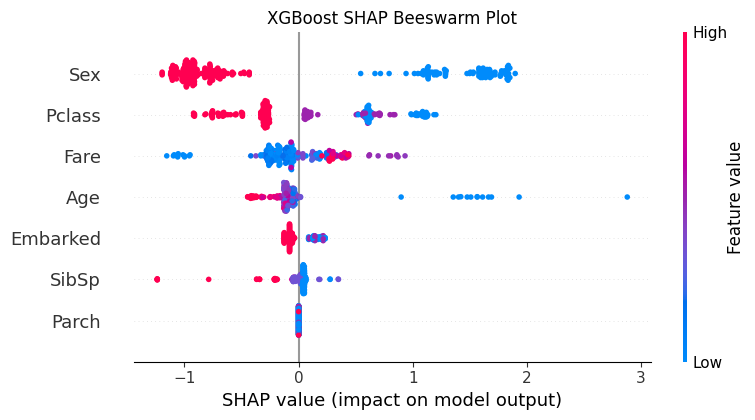


BOOSTING BENCHMARK RESULTS
      model  train_accuracy  val_accuracy  training_time_sec
0       LGB        0.889246      0.813433           0.017188
1       GBC        0.902087      0.809701           0.172432
2       XGB        0.886035      0.805970           0.031116
3  AdaBoost        0.796148      0.776119           0.402108


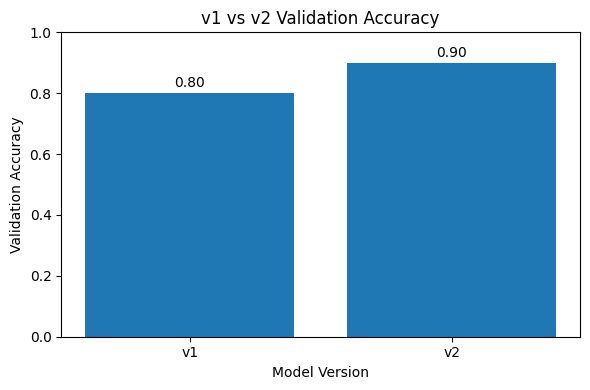

In [4]:
# ============================================================
# BOOSTING BENCHMARK - TITANIC SURVIVAL PREDICTION
# ============================================================

import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

import shap


# ============================================================
# 1. LOAD DATASET
# ============================================================

df = pd.read_csv("/content/Titanic-Dataset.csv")

print("Dataset:")
print(df)


# ============================================================
# 2. ENCODE CATEGORICAL VARIABLES
# ============================================================

df["Sex"] = df["Sex"].map({
    "female": 0,
    "male": 1
})

df["Embarked"] = df["Embarked"].map({
    "C": 0,
    "Q": 1,
    "S": 2
})

# Fill missing values
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])


# ============================================================
# 3. FEATURES AND TARGET
# ============================================================

X = df.drop(
    ["PassengerId", "Survived", "Name", "Ticket", "Cabin"],
    axis=1
)

y = df["Survived"]

print("\nFeatures:")
print(X)

print("\nTarget:")
print(y)


# ============================================================
# 4. TRAIN / VALIDATION SPLIT
# ============================================================

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("\nTraining samples:", len(X_train))
print("Validation samples:", len(X_val))


# ============================================================
# 5. ADABOOST - SAMPLE WEIGHTS
# ============================================================

ada = AdaBoostClassifier(
    n_estimators=10,
    learning_rate=0.5,
    random_state=42
)

# Initial equal weights
initial_weights = np.ones(len(X_train)) / len(X_train)

print("\nInitial AdaBoost sample weights:")
print(initial_weights)

ada.fit(X_train, y_train)

# Prediction
ada_pred = ada.predict(X_val)

print("\nAdaBoost Validation Accuracy:",
      accuracy_score(y_val, ada_pred))


# ============================================================
# 6. DISPLAY ADABOOST ESTIMATOR WEIGHTS
# ============================================================

print("\nAdaBoost estimator weights:")

for i, weight in enumerate(ada.estimator_weights_):
    print(f"Estimator {i + 1}: {weight:.4f}")


# ============================================================
# 7. XGBOOST WITH EARLY STOPPING
# ============================================================

xgb = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=3,
    random_state=42,
    eval_metric="logloss",
    early_stopping_rounds=20
)

xgb.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

xgb_pred = xgb.predict(X_val)

print("\nXGBoost Validation Accuracy:",
      accuracy_score(y_val, xgb_pred))

print("Best XGBoost iteration:",
      xgb.best_iteration)


# ============================================================
# 8. LIGHTGBM - TRAINING TIME
# ============================================================

lgb = LGBMClassifier(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=3,
    random_state=42,
    verbosity=-1
)

start_time = time.perf_counter()

lgb.fit(X_train, y_train)

end_time = time.perf_counter()

lgb_time = end_time - start_time

lgb_pred = lgb.predict(X_val)

print("\nLightGBM Validation Accuracy:",
      accuracy_score(y_val, lgb_pred))

print(f"LightGBM Training Time: {lgb_time:.6f} seconds")


# ============================================================
# 9. SHAP BEESWARM - XGBOOST
# ============================================================

explainer = shap.TreeExplainer(xgb)

shap_values = explainer.shap_values(X_val)

plt.figure(figsize=(8, 5))

shap.summary_plot(
    shap_values,
    X_val,
    plot_type="dot",
    show=False
)

plt.title("XGBoost SHAP Beeswarm Plot")
plt.tight_layout()
plt.show()


# ============================================================
# 10. BOOSTING BENCHMARK FUNCTION
# ============================================================

def boosting_benchmark(X_train, y_train, X_val, y_val):

    models = {

        "AdaBoost": AdaBoostClassifier(
            n_estimators=100,
            learning_rate=0.1,
            random_state=42
        ),

        "GBC": GradientBoostingClassifier(
            n_estimators=100,
            learning_rate=0.1,
            max_depth=3,
            random_state=42
        ),

        "XGB": XGBClassifier(
            n_estimators=100,
            learning_rate=0.1,
            max_depth=3,
            random_state=42,
            eval_metric="logloss"
        ),

        "LGB": LGBMClassifier(
            n_estimators=100,
            learning_rate=0.1,
            max_depth=3,
            random_state=42,
            verbosity=-1
        )
    }

    results = []

    for name, model in models.items():

        start_time = time.perf_counter()

        model.fit(X_train, y_train)

        end_time = time.perf_counter()

        train_time = end_time - start_time

        train_pred = model.predict(X_train)
        val_pred = model.predict(X_val)

        train_accuracy = accuracy_score(
            y_train,
            train_pred
        )

        val_accuracy = accuracy_score(
            y_val,
            val_pred
        )

        results.append({
            "model": name,
            "train_accuracy": train_accuracy,
            "val_accuracy": val_accuracy,
            "training_time_sec": train_time
        })

    results_df = pd.DataFrame(results)

    # Sort by validation accuracy
    results_df = results_df.sort_values(
        by="val_accuracy",
        ascending=False
    ).reset_index(drop=True)

    return results_df


# ============================================================
# 11. RUN BOOSTING BENCHMARK
# ============================================================

results = boosting_benchmark(
    X_train,
    y_train,
    X_val,
    y_val
)

print("\n==========================================")
print("BOOSTING BENCHMARK RESULTS")
print("==========================================")

print(results)


# ============================================================
# 12. V1 vs V2 BAR CHART
# ============================================================

# Example:
# v1 = baseline model
# v2 = improved model

# Replace these values with your actual results
v1_accuracy = 0.80
v2_accuracy = 0.90

versions = ["v1", "v2"]
accuracies = [v1_accuracy, v2_accuracy]

plt.figure(figsize=(6, 4))

plt.bar(
    versions,
    accuracies
)

plt.ylabel("Validation Accuracy")
plt.xlabel("Model Version")
plt.title("v1 vs v2 Validation Accuracy")

plt.ylim(0, 1)

for i, value in enumerate(accuracies):
    plt.text(
        i,
        value + 0.02,
        f"{value:.2f}",
        ha="center"
    )

plt.tight_layout()
plt.show()